# Speculative Decoding Systems Benchmark — Phase 1
**A Systems Study of Speculative Decoding for LLM Inference**  
CS590 ML Systems · Duke University · Zanwen Fu

Three families benchmarked on T4 GPU:
1. **Baseline** — Standard autoregressive decoding
2. **Linear Draft-Verify** — HuggingFace assisted generation (Family 1)
3. **Prompt Lookup Decoding** — Retrieval-based / model-free (Family 3)


In [1]:
!pip install -q transformers accelerate bitsandbytes datasets matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.4 MB/s eta 0:00:00


In [2]:
from huggingface_hub import notebook_login
notebook_login()

In [3]:
import torch
import time
import json
import gc
import numpy as np
from typing import Optional

assert torch.cuda.is_available(), "No GPU — set Runtime > T4 GPU"
props = torch.cuda.get_device_properties(0)
print(f"GPU: {props.name} ({props.total_memory / 1e9:.1f} GB)")
print(f"CUDA: {torch.version.cuda}  PyTorch: {torch.__version__}")

GPU: Tesla T4 (15.6 GB)
CUDA: 12.8  PyTorch: 2.10.0+cu128


In [4]:
# ============================================================
# Configuration
# ============================================================
TARGET_MODEL = "meta-llama/Llama-3.2-3B"   # ~6 GB fp16, fits T4
DRAFT_MODEL  = "meta-llama/Llama-3.2-1B"   # ~2 GB fp16, same tokenizer guaranteed

MAX_NEW_TOKENS = 128
NUM_WARMUP     = 3
NUM_TRIALS     = 30

DRAFT_K_VALUES       = [3, 5, 7, 10]
PROMPT_LOOKUP_VALUES = [3, 5, 7, 10]
TEMPERATURES         = [0.0, 0.6, 0.8]

PROMPTS = [
    # General knowledge
    "The history of artificial intelligence began in the 1950s when researchers first",
    "In computer science, a hash table is a data structure that implements an associative",
    "The process of photosynthesis converts light energy into chemical energy through",
    # Code
    'def fibonacci(n):\n    """Calculate the nth Fibonacci number."""\n    if n <= 1:\n        return n\n',
    "# Python implementation of binary search\ndef binary_search(arr, target):\n",
    # Summarization-style (high repetition — should favor prompt lookup)
    "Summarize the following: Machine learning is a subset of artificial intelligence that focuses on building systems that learn from data. Machine learning algorithms use historical data as input to predict new output values. Machine learning is",
    # Instruction
    "Write a detailed explanation of how TCP/IP networking works, starting from",
    "Explain the difference between a stack and a queue data structure. A stack",
    # Longer context
    "The transformer architecture was introduced in the paper Attention is All You Need by Vaswani et al. in 2017. It replaced recurrent neural networks with self-attention mechanisms, enabling parallel processing of sequences. The key innovation was the multi-head attention mechanism, which allows the model to attend to different parts of the input simultaneously. Since then, transformers have become the foundation for",
    "Large language models are trained on massive datasets of text from the internet. During training, the model learns to predict the next token in a sequence given all previous tokens. This autoregressive training objective means that at inference time, the model generates text one token at a time, each conditioned on all previously generated tokens. This sequential nature creates a fundamental bottleneck because",
]

PROMPT_LABELS = [
    "general_1", "general_2", "general_3",
    "code_1", "code_2", "summarization",
    "instruction_1", "instruction_2",
    "long_ctx_1", "long_ctx_2",
]

print(f"Target: {TARGET_MODEL}")
print(f"Draft:  {DRAFT_MODEL}")
print(f"Prompts: {len(PROMPTS)}, Trials/config: {NUM_TRIALS}, Max tokens: {MAX_NEW_TOKENS}")

Target: meta-llama/Llama-3.2-3B
Draft:  meta-llama/Llama-3.2-1B
Prompts: 10, Trials/config: 30, Max tokens: 128


In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

print("Loading target model...")
target_model = AutoModelForCausalLM.from_pretrained(
    TARGET_MODEL, torch_dtype=torch.float16, device_map="auto",
)
target_model.eval()

tokenizer = AutoTokenizer.from_pretrained(TARGET_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

alloc_target = torch.cuda.memory_allocated() / 1e9
print(f"  Target loaded: {alloc_target:.2f} GB")

print("Loading draft model...")
draft_model = AutoModelForCausalLM.from_pretrained(
    DRAFT_MODEL, torch_dtype=torch.float16, device_map="auto",
)
draft_model.eval()

alloc_total = torch.cuda.memory_allocated() / 1e9
print(f"  Draft loaded: {alloc_total:.2f} GB total (draft overhead: {alloc_total - alloc_target:.3f} GB)")
print("\nModels ready. Verifying quick generation...")

# Quick sanity check
test_input = tokenizer("Hello", return_tensors="pt").to(target_model.device)
with torch.inference_mode():
    out = target_model.generate(**test_input, max_new_tokens=5, pad_token_id=tokenizer.pad_token_id)
print(f"Sanity check: {tokenizer.decode(out[0], skip_special_tokens=True)}")

Loading target model...


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

  Draft loaded: 8.90 GB total (draft overhead: 2.473 GB)

Models ready. Verifying quick generation...
Sanity check: Hello, my name is Sh


In [7]:
# ============================================================
# Benchmark engine — robust, with intermediate saves
# ============================================================

ALL_RESULTS = []     # raw per-trial records
ALL_SUMMARIES = []   # aggregated summaries

def timed_generate(model, inputs, gen_kwargs):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.inference_mode():
        output = model.generate(**inputs, **gen_kwargs)
    torch.cuda.synchronize()
    t1 = time.perf_counter()
    return output, t1 - t0


def run_benchmark(name, model, tokenizer, prompts, gen_kwargs,
                  num_warmup=NUM_WARMUP, num_trials=NUM_TRIALS):
    """
    Run benchmark with given gen_kwargs dict (NOT a function).
    Returns list of per-trial dicts.
    """
    results = []

    # Warmup
    for _ in range(num_warmup):
        inp = tokenizer(prompts[0], return_tensors="pt").to(model.device)
        with torch.inference_mode():
            model.generate(**inp, **gen_kwargs)

    torch.cuda.reset_peak_memory_stats()

    for trial in range(num_trials):
        pidx = trial % len(prompts)
        inp = tokenizer(prompts[pidx], return_tensors="pt").to(model.device)
        prompt_len = inp["input_ids"].shape[1]

        output, wall = timed_generate(model, inp, gen_kwargs)
        gen_tok = output.shape[1] - prompt_len

        results.append({
            "method": name,
            "prompt_idx": pidx,
            "prompt_tokens": prompt_len,
            "gen_tokens": gen_tok,
            "wall_sec": round(wall, 5),
            "tok_per_sec": round(gen_tok / wall, 2) if wall > 0 else 0,
            "peak_gpu_mb": round(torch.cuda.max_memory_allocated() / 1e6, 1),
        })

    return results


def summarize(results, baseline_tps=None):
    tps = [r["tok_per_sec"] for r in results]
    walls = [r["wall_sec"] for r in results]
    mean_tps = float(np.mean(tps))
    speedup = mean_tps / baseline_tps if baseline_tps else 1.0
    return {
        "method": results[0]["method"],
        "mean_tok_sec": round(mean_tps, 2),
        "median_tok_sec": round(float(np.median(tps)), 2),
        "std_tok_sec": round(float(np.std(tps)), 2),
        "p5_tok_sec": round(float(np.percentile(tps, 5)), 2),
        "p95_tok_sec": round(float(np.percentile(tps, 95)), 2),
        "mean_wall_sec": round(float(np.mean(walls)), 4),
        "p95_wall_sec": round(float(np.percentile(walls, 95)), 4),
        "speedup": round(speedup, 3),
        "peak_gpu_mb": max(r["peak_gpu_mb"] for r in results),
        "n_trials": len(results),
    }


def save_checkpoint(tag=""):
    """Save intermediate results so nothing is lost on crash."""
    suffix = f"_{tag}" if tag else ""
    with open(f"results_raw{suffix}.json", "w") as f:
        json.dump(ALL_RESULTS, f, indent=2)
    with open(f"results_summary{suffix}.json", "w") as f:
        json.dump(ALL_SUMMARIES, f, indent=2)
    print(f"  [checkpoint saved: {len(ALL_RESULTS)} trials, {len(ALL_SUMMARIES)} summaries]")


def print_table(summaries):
    print(f"\n{'Method':<42} {'Mean T/s':>9} {'Med T/s':>9} {'Std':>7} {'p95 Lat':>9} {'Speedup':>8} {'GPU MB':>8}")
    print("-" * 100)
    for s in summaries:
        print(f"{s['method']:<42} {s['mean_tok_sec']:>9.2f} {s['median_tok_sec']:>9.2f} "
              f"{s['std_tok_sec']:>7.2f} {s['p95_wall_sec']:>9.4f} {s['speedup']:>7.3f}x {s['peak_gpu_mb']:>8.0f}")
    print()

print("Benchmark engine ready.")

Benchmark engine ready.


## Experiment 1: Baseline Autoregressive (Greedy)

In [8]:
print("=" * 60)
print("EXP 1: Baseline Autoregressive (greedy)")
print("=" * 60)

baseline_kwargs = dict(
    max_new_tokens=MAX_NEW_TOKENS,
    do_sample=False,
    pad_token_id=tokenizer.pad_token_id,
)

baseline_results = run_benchmark(
    "autoregressive_greedy", target_model, tokenizer, PROMPTS, baseline_kwargs
)
ALL_RESULTS.extend(baseline_results)

baseline_summary = summarize(baseline_results)
ALL_SUMMARIES.append(baseline_summary)
BASELINE_TPS = baseline_summary["mean_tok_sec"]

print(f"\nBaseline: {BASELINE_TPS:.2f} tok/s  |  Latency: {baseline_summary['mean_wall_sec']:.3f}s")
save_checkpoint("after_baseline")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


EXP 1: Baseline Autoregressive (greedy)

Baseline: 26.42 tok/s  |  Latency: 4.275s
  [checkpoint saved: 30 trials, 1 summaries]


## Experiment 2: Linear Speculative Decoding — Sweep k

In [9]:
print("=" * 60)
print("EXP 2: Linear Draft-Verify (greedy, sweep k)")
print("=" * 60)

for k in DRAFT_K_VALUES:
    print(f"\n--- k = {k} ---")

    sd_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        assistant_model=draft_model,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        # Fix k to a constant so the heuristic doesn't auto-adjust
        num_assistant_tokens=k,
        num_assistant_tokens_schedule="constant",
    )

    results = run_benchmark(
        f"linear_SD_k{k}_greedy", target_model, tokenizer, PROMPTS, sd_kwargs
    )
    ALL_RESULTS.extend(results)

    s = summarize(results, BASELINE_TPS)
    ALL_SUMMARIES.append(s)
    print(f"  {s['mean_tok_sec']:.2f} tok/s  |  {s['speedup']:.3f}x speedup")

save_checkpoint("after_linear_sd")

Passing `generation_config` together with generation-related arguments=({'min_new_tokens', 'max_new_tokens', 'use_cache'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_c

EXP 2: Linear Draft-Verify (greedy, sweep k)

--- k = 3 ---


Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_

  26.68 tok/s  |  1.010x speedup

--- k = 5 ---


Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_

  25.83 tok/s  |  0.977x speedup

--- k = 7 ---


Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_

  25.54 tok/s  |  0.967x speedup

--- k = 10 ---


Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_

  24.34 tok/s  |  0.921x speedup
  [checkpoint saved: 150 trials, 5 summaries]


## Experiment 3: Prompt Lookup Decoding — Sweep n

In [10]:
print("=" * 60)
print("EXP 3: Prompt Lookup Decoding (greedy, sweep n)")
print("=" * 60)

for n in PROMPT_LOOKUP_VALUES:
    print(f"\n--- n = {n} ---")

    pl_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        prompt_lookup_num_tokens=n,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )

    results = run_benchmark(
        f"prompt_lookup_n{n}_greedy", target_model, tokenizer, PROMPTS, pl_kwargs
    )
    ALL_RESULTS.extend(results)

    s = summarize(results, BASELINE_TPS)
    ALL_SUMMARIES.append(s)
    print(f"  {s['mean_tok_sec']:.2f} tok/s  |  {s['speedup']:.3f}x speedup")

save_checkpoint("after_prompt_lookup")

EXP 3: Prompt Lookup Decoding (greedy, sweep n)

--- n = 3 ---
  33.69 tok/s  |  1.275x speedup

--- n = 5 ---
  34.77 tok/s  |  1.316x speedup

--- n = 7 ---
  35.66 tok/s  |  1.350x speedup

--- n = 10 ---
  36.68 tok/s  |  1.388x speedup
  [checkpoint saved: 270 trials, 9 summaries]


## Experiment 4: Temperature Sensitivity (Linear SD, k=5)

In [11]:
print("=" * 60)
print("EXP 4: Temperature Sensitivity")
print("=" * 60)

TEMP_K = 5

for temp in TEMPERATURES:
    if temp == 0.0:
        continue  # already have greedy

    print(f"\n--- Temperature = {temp} ---")

    # Baseline at this temperature
    base_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=temp,
        top_p=0.9,
        pad_token_id=tokenizer.pad_token_id,
    )
    base_res = run_benchmark(
        f"autoregressive_T{temp}", target_model, tokenizer, PROMPTS, base_kwargs
    )
    ALL_RESULTS.extend(base_res)
    base_s = summarize(base_res)
    ALL_SUMMARIES.append(base_s)
    base_tps_temp = base_s["mean_tok_sec"]

    # Linear SD at this temperature
    sd_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        assistant_model=draft_model,
        do_sample=True,
        temperature=temp,
        top_p=0.9,
        pad_token_id=tokenizer.pad_token_id,
        num_assistant_tokens=TEMP_K,
        num_assistant_tokens_schedule="constant",
    )
    sd_res = run_benchmark(
        f"linear_SD_k{TEMP_K}_T{temp}", target_model, tokenizer, PROMPTS, sd_kwargs
    )
    ALL_RESULTS.extend(sd_res)
    sd_s = summarize(sd_res, base_tps_temp)
    ALL_SUMMARIES.append(sd_s)

    print(f"  Baseline T={temp}: {base_tps_temp:.2f} tok/s")
    print(f"  SD k={TEMP_K} T={temp}: {sd_s['mean_tok_sec']:.2f} tok/s  |  {sd_s['speedup']:.3f}x")

save_checkpoint("after_temperature")

EXP 4: Temperature Sensitivity

--- Temperature = 0.6 ---


Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_

  Baseline T=0.6: 25.35 tok/s
  SD k=5 T=0.6: 19.51 tok/s  |  0.770x

--- Temperature = 0.8 ---


Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=0) and `min_length`(=0) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_

  Baseline T=0.8: 26.44 tok/s
  SD k=5 T=0.8: 22.04 tok/s  |  0.833x
  [checkpoint saved: 390 trials, 13 summaries]


## Results Summary

In [12]:
print_table(ALL_SUMMARIES)
save_checkpoint("final")


Method                                      Mean T/s   Med T/s     Std   p95 Lat  Speedup   GPU MB
----------------------------------------------------------------------------------------------------
autoregressive_greedy                          26.42     27.09    1.48    5.3018   1.000x     8940
linear_SD_k3_greedy                            26.68     24.46    4.99    5.9745   1.010x     9006
linear_SD_k5_greedy                            25.83     24.09    4.61    6.0572   0.977x     9006
linear_SD_k7_greedy                            25.54     24.14    4.36    6.1112   0.967x     9006
linear_SD_k10_greedy                           24.34     22.73    4.68    6.3906   0.921x     9006
prompt_lookup_n3_greedy                        33.69     30.43    8.78    4.8766   1.275x     8945
prompt_lookup_n5_greedy                        34.77     30.41   12.15    4.9172   1.316x     8948
prompt_lookup_n7_greedy                        35.66     31.07   12.74    4.9189   1.350x     8950
prompt_

## Per-Prompt Analysis

In [13]:
# Analyze which prompt types benefit most from each method

def get_prompt_avg(method_name):
    by_prompt = {}
    for r in ALL_RESULTS:
        if r["method"] == method_name:
            by_prompt.setdefault(r["prompt_idx"], []).append(r["tok_per_sec"])
    return {k: float(np.mean(v)) for k, v in by_prompt.items()}

baseline_by_prompt = get_prompt_avg("autoregressive_greedy")
sd5_by_prompt = get_prompt_avg("linear_SD_k5_greedy")
pl5_by_prompt = get_prompt_avg("prompt_lookup_n5_greedy")

print(f"{'Prompt':<16} {'Baseline':>10} {'SD k=5':>10} {'SD spdup':>10} {'PL n=5':>10} {'PL spdup':>10}")
print("-" * 70)
for pidx in sorted(baseline_by_prompt.keys()):
    label = PROMPT_LABELS[pidx] if pidx < len(PROMPT_LABELS) else f"p{pidx}"
    b = baseline_by_prompt.get(pidx, 1)
    sd = sd5_by_prompt.get(pidx, 0)
    pl = pl5_by_prompt.get(pidx, 0)
    print(f"{label:<16} {b:>10.2f} {sd:>10.2f} {sd/b:>9.3f}x {pl:>10.2f} {pl/b:>9.3f}x")

Prompt             Baseline     SD k=5   SD spdup     PL n=5   PL spdup
----------------------------------------------------------------------
general_1             27.17      22.29     0.820x      33.01     1.215x
general_2             25.79      25.47     0.988x      44.01     1.707x
general_3             26.67      25.58     0.959x      28.82     1.081x
code_1                27.22      36.75     1.350x      30.14     1.107x
code_2                25.42      22.10     0.869x      29.18     1.148x
summarization         26.51      22.51     0.849x      31.71     1.196x
instruction_1         27.02      25.80     0.955x      27.01     1.000x
instruction_2         25.94      30.10     1.160x      67.72     2.611x
long_ctx_1            26.53      22.73     0.857x      27.37     1.032x
long_ctx_2            25.88      24.92     0.963x      28.75     1.111x


## Visualization

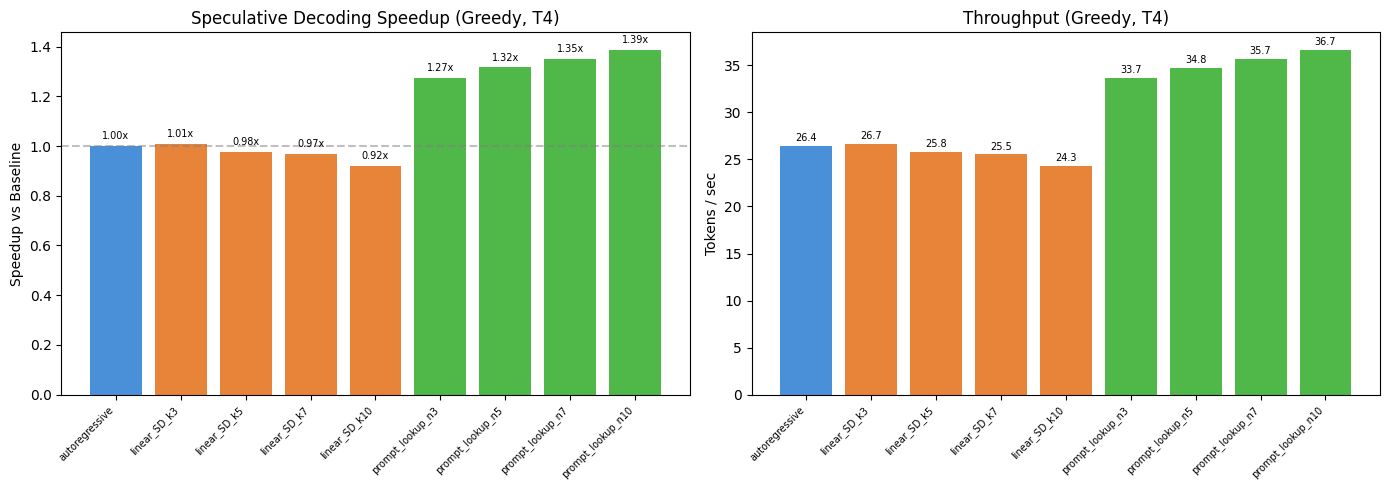

Saved phase1_results.png


In [14]:
import matplotlib.pyplot as plt

# Filter greedy-only summaries for clean chart
greedy = [s for s in ALL_SUMMARIES if s["method"].endswith("greedy")]
methods = [s["method"].replace("_greedy", "") for s in greedy]
speedups = [s["speedup"] for s in greedy]
tok_secs = [s["mean_tok_sec"] for s in greedy]

def get_color(m):
    if "autoregressive" in m: return "#4A90D9"
    if "linear" in m: return "#E8833A"
    if "prompt_lookup" in m: return "#50B848"
    return "#999999"

colors = [get_color(m) for m in methods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Speedup
bars1 = ax1.bar(range(len(methods)), speedups, color=colors)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(methods, rotation=45, ha="right", fontsize=7)
ax1.set_ylabel("Speedup vs Baseline")
ax1.set_title("Speculative Decoding Speedup (Greedy, T4)")
ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
for bar, sp in zip(bars1, speedups):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{sp:.2f}x", ha="center", va="bottom", fontsize=7)

# Throughput
bars2 = ax2.bar(range(len(methods)), tok_secs, color=colors)
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("Tokens / sec")
ax2.set_title("Throughput (Greedy, T4)")
for bar, ts in zip(bars2, tok_secs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{ts:.1f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("phase1_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved phase1_results.png")

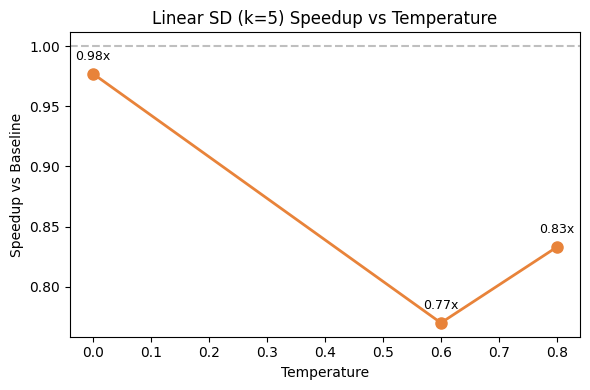

Saved phase1_temperature.png


In [15]:
# Temperature sensitivity chart
temp_data = {}
for s in ALL_SUMMARIES:
    if "linear_SD_k5" in s["method"]:
        if "greedy" in s["method"]:
            temp_data[0.0] = s["speedup"]
        for t in [0.6, 0.8]:
            if f"T{t}" in s["method"]:
                temp_data[t] = s["speedup"]

if len(temp_data) > 1:
    temps = sorted(temp_data.keys())
    spds = [temp_data[t] for t in temps]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(temps, spds, "o-", color="#E8833A", linewidth=2, markersize=8)
    ax.set_xlabel("Temperature")
    ax.set_ylabel("Speedup vs Baseline")
    ax.set_title("Linear SD (k=5) Speedup vs Temperature")
    ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
    for t, sp in zip(temps, spds):
        ax.annotate(f"{sp:.2f}x", (t, sp), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("phase1_temperature.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved phase1_temperature.png")
else:
    print("Not enough temperature data to plot.")

In [16]:
# Final comprehensive save
print("\n" + "=" * 60)
print("FINAL RESULTS — copy for report")
print("=" * 60)
for s in ALL_SUMMARIES:
    print(f"  {s['method']}: {s['mean_tok_sec']} tok/s, "
          f"speedup={s['speedup']}x, p95_lat={s['p95_wall_sec']}s, "
          f"gpu={s['peak_gpu_mb']}MB")

save_checkpoint("final")
print("\nDone! Download results_raw_final.json and results_summary_final.json")


FINAL RESULTS — copy for report
  autoregressive_greedy: 26.42 tok/s, speedup=1.0x, p95_lat=5.3018s, gpu=8940.2MB
  linear_SD_k3_greedy: 26.68 tok/s, speedup=1.01x, p95_lat=5.9745s, gpu=9006.4MB
  linear_SD_k5_greedy: 25.83 tok/s, speedup=0.977x, p95_lat=6.0572s, gpu=9006.4MB
  linear_SD_k7_greedy: 25.54 tok/s, speedup=0.967x, p95_lat=6.1112s, gpu=9006.4MB
  linear_SD_k10_greedy: 24.34 tok/s, speedup=0.921x, p95_lat=6.3906s, gpu=9006.4MB
  prompt_lookup_n3_greedy: 33.69 tok/s, speedup=1.275x, p95_lat=4.8766s, gpu=8944.8MB
  prompt_lookup_n5_greedy: 34.77 tok/s, speedup=1.316x, p95_lat=4.9172s, gpu=8947.6MB
  prompt_lookup_n7_greedy: 35.66 tok/s, speedup=1.35x, p95_lat=4.9189s, gpu=8950.3MB
  prompt_lookup_n10_greedy: 36.68 tok/s, speedup=1.388x, p95_lat=4.8566s, gpu=8955.2MB
  autoregressive_T0.6: 25.35 tok/s, speedup=1.0x, p95_lat=5.3779s, gpu=8941.3MB
  linear_SD_k5_T0.6: 19.51 tok/s, speedup=0.77x, p95_lat=10.3416s, gpu=9015.5MB
  autoregressive_T0.8: 26.44 tok/s, speedup=1.0x, p95